# Setup and Data Loading

In [2]:
from textblob import TextBlob
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


# 1. Directory Setup
KAGGLE_DATA_DIR = Path("/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3")
LOCAL_DATA_DIR = Path("./data")
DATA_DIR = KAGGLE_DATA_DIR if KAGGLE_DATA_DIR.exists() else LOCAL_DATA_DIR

# 2. Load Data
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

# 3. Identify Data Types
print("--- Training Data Info ---")
train_df.info()

--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.2+ KB


# Data Cleaning (Missing Values, Duplicates, Outliers)

In [15]:
print("--- Missing Values ---")
print(train_df.isnull().sum())
# Note: Missing values in feature_1, 2, and 3 will be handled via SimpleImputer in the pipeline.

print("\n--- Duplicates ---")
duplicate_count = train_df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
  train_df = train_df.drop_duplicates()
  print("Duplicates dropped.")

print("\n--- Outliers (IQR Method) ---")
num_cols = ['feature_1', 'feature_2', 'feature_3']
for col in num_cols:
  Q1 = train_df[col].quantile(0.25)
  Q3 = train_df[col].quantile(0.75)
  IQR = Q3 - Q1
  outliers = train_df[(train_df[col] < Q1 - 1.5 * IQR) | (train_df[col] > Q3 + 1.5 * IQR)]
  print(f"{col} outliers: {len(outliers)} ({len(outliers)/len(train_df)*100:.2f}%)")

--- Missing Values ---
id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64

--- Duplicates ---
Duplicate rows found: 0

--- Outliers (IQR Method) ---
feature_1 outliers: 45 (0.64%)
feature_2 outliers: 150 (2.14%)
feature_3 outliers: 331 (4.73%)


# Visualizations and Insights

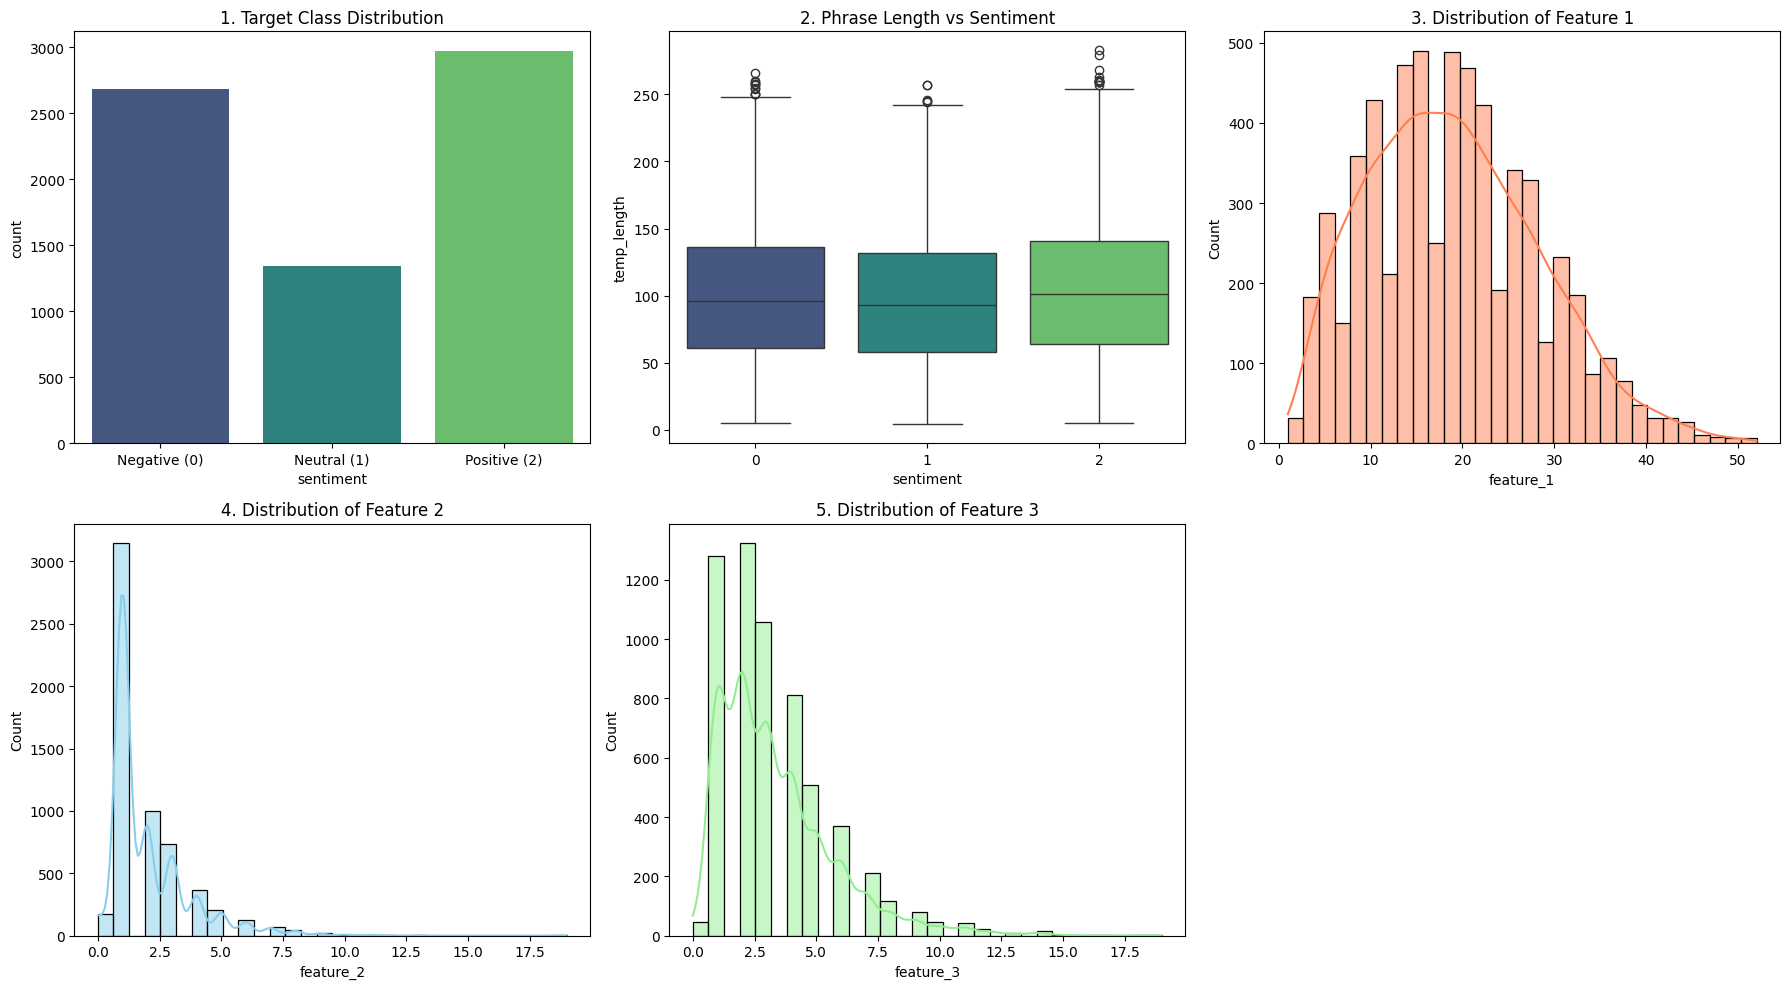

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Visualization 1: Target Distribution
_ = sns.countplot(data=train_df, x='sentiment', ax=axes[0], palette='viridis')
_ = axes[0].set_title("1. Target Class Distribution")
_ = axes[0].set_xticks([0, 1, 2])
_ = axes[0].set_xticklabels(['Negative (0)', 'Neutral (1)', 'Positive (2)'])

# Visualization 2: Phrase Length by Sentiment
train_df['temp_length'] = train_df['phrase'].fillna('').str.len()
_ = sns.boxplot(data=train_df, x='sentiment', y='temp_length', ax=axes[1], palette='viridis')
_ = axes[1].set_title("2. Phrase Length vs Sentiment")
_ = train_df.drop(columns=['temp_length'], inplace=True)

# Visualization 3: Feature 1 Distribution
_ = sns.histplot(train_df['feature_1'].dropna(), bins=30, kde=True, ax=axes[2], color='coral')
_ = axes[2].set_title("3. Distribution of Feature 1")

# Visualization 4: Feature 2 Distribution
_ = sns.histplot(train_df['feature_2'].dropna(), bins=30, kde=True, ax=axes[3], color='skyblue')
_ = axes[3].set_title("4. Distribution of Feature 2")

# Visualization 5: Feature 3 Distribution
_ = sns.histplot(train_df['feature_3'].dropna(), bins=30, kde=True, ax=axes[4], color='lightgreen')
_ = axes[4].set_title("5. Distribution of Feature 3")

# Hide the 6th empty subplot to keep it clean
_ = axes[5].axis('off')

_ = plt.tight_layout()

# Feature Engineering

In [19]:
def add_engineered_features(df):
  df = df.copy()
  df['phrase'] = df['phrase'].fillna('')

  # TextBlob
  df['polarity'] = [TextBlob(str(text)).sentiment.polarity for text in df['phrase']]
  df['subjectivity'] = [TextBlob(str(text)).sentiment.subjectivity for text in df['phrase']]

  # Hand-crafted text features
  df['char_len'] = df['phrase'].str.len()
  df['word_count'] = df['phrase'].str.split().str.len()
  df['avg_word_len'] = df['phrase'].apply(lambda x: np.mean(
    [len(w) for w in x.split()]) if x.split() else 0)
  df['exclaim_count'] = df['phrase'].str.count('!')
  df['question_count'] = df['phrase'].str.count(r'\?')
  df['upper_ratio'] = df['phrase'].apply(
      lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))

  # Keyword counts
  neg_words, pos_words = ['not', 'no', 'never', 'bad', 'worst'], [
      'great', 'good', 'excellent', 'amazing', 'best']
  df['neg_word_count'] = df['phrase'].apply(lambda x: sum(x.lower().count(w) for w in neg_words))
  df['pos_word_count'] = df['phrase'].apply(lambda x: sum(x.lower().count(w) for w in pos_words))

  return df


# Separate targets and engineer features
X = train_df.drop(columns=['id', 'sentiment'])
y = train_df['sentiment']
X_test = test_df.drop(columns=['id'])

X = add_engineered_features(X)
X_test = add_engineered_features(X_test)

# Print shapes to confirm feature engineering
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_test shape: {X_test.shape}")

X shape: (7000, 14)
y shape: (7000,)
X_test shape: (1700, 14)


# Preprocessing and Validation Split

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Split Data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Feature categorisation
ALL_NUM_FEATURES = [col for col in X.columns if col != 'phrase']
TEXT_FEATURE = 'phrase'

# Build Pipeline (Impute -> Scale for numbers; TF-IDF for text)
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, min_df=2,
     max_df=0.95, ngram_range=(1, 2), sublinear_tf=True))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, ALL_NUM_FEATURES),
    ('text', text_pipeline, TEXT_FEATURE)
])

# Process Validation data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed validation shape: {X_val_processed.shape}")

Processed training shape: (6300, 10013)
Processed validation shape: (700, 10013)


# Model Building (7 Models)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(C=5, max_iter=1000, solver='saga', n_jobs=-1, class_weight='balanced'),
    'Linear SVC': LinearSVC(C=1.0, max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=500, max_depth=30, min_samples_leaf=2, n_jobs=-1, random_state=42, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=500, max_depth=30, min_samples_leaf=2, n_jobs=-1, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=15, metric='cosine', n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=500, max_depth=10, learning_rate=0.05, num_leaves=63, n_jobs=-1, random_state=42, verbosity=-1, class_weight='balanced'),
}

baseline_results = {}

print(f"{'Model':<25} {'Val Accuracy'}")
print("-" * 40)
for name, model in models.items():
  model.fit(X_train_processed, y_train)
  acc = accuracy_score(y_val, model.predict(X_val_processed))
  baseline_results[name] = round(acc, 4)
  print(f"{name:<25} {acc:.4f}")

Model                     Val Accuracy
----------------------------------------


,penalty,'l2'
,dual,False
,tol,0.0001
,C,5
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


Logistic Regression       0.6329


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


Linear SVC                0.6229


...

Gradient Boosting         0.6129


,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'cosine'
,metric_params,None
,n_jobs,-1


KNN                       0.5257


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,10
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


LightGBM                  0.5943


# Hyperparameter Tuning (3 Models)

In [ ]:
# Set to True before committing to Kaggle to skip the tuning process
IS_SUBMISSION_MODE = False

In [ ]:
from sklearn.model_selection import GridSearchCV

tuning_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, class_weight='balanced'),
        'params': {'C': [0.5, 1, 5]}
    },
    'Linear SVC': {
        'model': LinearSVC(max_iter=2000, class_weight='balanced'),
        'params': {'C': [0.1, 0.5, 1.0]}
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]}
    }
}

tuned_results = {}
best_models = {}

if not IS_SUBMISSION_MODE:
    print("Starting Hyperparameter Tuning...")
    for name, config in tuning_configs.items():
        gs = GridSearchCV(config['model'], config['params'], cv=3, scoring='accuracy', n_jobs=-1)
        gs.fit(X_train_processed, y_train)
        val_acc = accuracy_score(y_val, gs.predict(X_val_processed))
        
        tuned_results[name] = round(val_acc, 4)
        best_models[name] = gs.best_estimator_
        print(f"[{name}] Best Params: {gs.best_params_} | New Acc: {val_acc:.4f}")
else:
    print("Submission mode enabled: Skipping Hyperparameter Tuning to save time.")

Starting Hyperparameter Tuning...


,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [0.5, 1, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


[Logistic Regression] Best Params: {'C': 5} | New Acc: 0.6329


,estimator,LinearSVC(cla...max_iter=2000)
,param_grid,"{'C': [0.1, 0.5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


[Linear SVC] Best Params: {'C': 0.5} | New Acc: 0.6286


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


[Gradient Boosting] Best Params: {'learning_rate': 0.1, 'n_estimators': 200} | New Acc: 0.6143


# Model Performance Comparison

In [14]:
print("=== Final Model Performance Comparison ===")
print(f"{'Model Name':<30} | {'Base Accuracy':<15} | {'Tuned Accuracy':<15}")
print("-" * 65)

for name in models.keys():
  base_acc = baseline_results.get(name, "N/A")
  tuned_acc = tuned_results.get(name, "Not Tuned")
  print(f"{name:<30} | {str(base_acc):<15} | {str(tuned_acc):<15}")

# Find and print the absolute best model overall for reporting purposes
all_accuracies = {**baseline_results, **tuned_results}
best_model_name = max(all_accuracies, key=all_accuracies.get)
print(f"\nWinner: {best_model_name} with {all_accuracies[best_model_name]} accuracy.")

=== Final Model Performance Comparison ===
Model Name                     | Base Accuracy   | Tuned Accuracy 
-----------------------------------------------------------------
Logistic Regression            | 0.6329          | 0.6329         
Linear SVC                     | 0.6229          | 0.6286         
Random Forest                  | 0.5843          | Not Tuned      
Extra Trees                    | 0.5857          | Not Tuned      
Gradient Boosting              | 0.6129          | 0.6143         
KNN                            | 0.5257          | Not Tuned      
LightGBM                       | 0.5943          | Not Tuned      

Winner: Logistic Regression with 0.6329 accuracy.


# Final Full Training & Submission

In [13]:
# 1. Expand Preprocessor for Full Data
text_pipeline_full = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 3),
        sublinear_tf=True
    ))
])

preprocessor_full = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, ALL_NUM_FEATURES),
    ('text', text_pipeline_full, TEXT_FEATURE)
])

# 2. Process 100% of the data
X_full_processed = preprocessor_full.fit_transform(X)
X_test_processed_full = preprocessor_full.transform(X_test)

# 3. Instantiate and Train a Fresh Linear SVC Model
final_svc = LinearSVC(C=0.5, max_iter=2000)
final_svc.fit(X_full_processed, y)

# 4. Generate Predictions and Submission File
test_preds = final_svc.predict(X_test_processed_full)

submission = pd.DataFrame({
    'id': test_df['id'],
    'sentiment': test_preds
})

submission.to_csv('./submission.csv', index=False)
print(f"Submission saved! Shape: {submission.shape}")
print(submission.head())

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.5
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


Submission saved! Shape: (1700, 2)
   id  sentiment
0   0          0
1   1          2
2   2          2
3   3          2
4   4          0
